# Student Placement Prediction System

**Prerequisites**
Before running the notebook, ensure you have the necessary libraries installed. You can install them by running this command in a terminal or a notebook cell:
```Bash
pip install pandas scikit-learn joblib
```

---
### Import necessary libraries

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style="whitegrid")
print("Libraries imported successfully with visualization tools.")

Libraries imported successfully with visualization tools.


---
### Load the dataset

In [2]:
df = pd.read_csv('placement_data.csv')

# Display first 5 rows to verify ingestion
print("Data Preview:")
display(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Data Preview:


,Student_ID,GPA,Internships,Projects,Soft_Skills_Score,Placement_Status
0,1,3.8,3,4,9,Placed
1,2,2.4,0,1,5,Not Placed
2,3,3.2,1,2,7,Placed
3,4,3.9,4,5,10,Placed
4,5,2.1,0,0,4,Not Placed



Missing Values:
Student_ID           0
GPA                  0
Internships          0
Projects             0
Soft_Skills_Score    0
Placement_Status     0
dtype: int64


---
### Exploratory Data Analysis (EDA)
Visualizing the relationships between student metrics and their eventual placement status to uncover baseline trends.

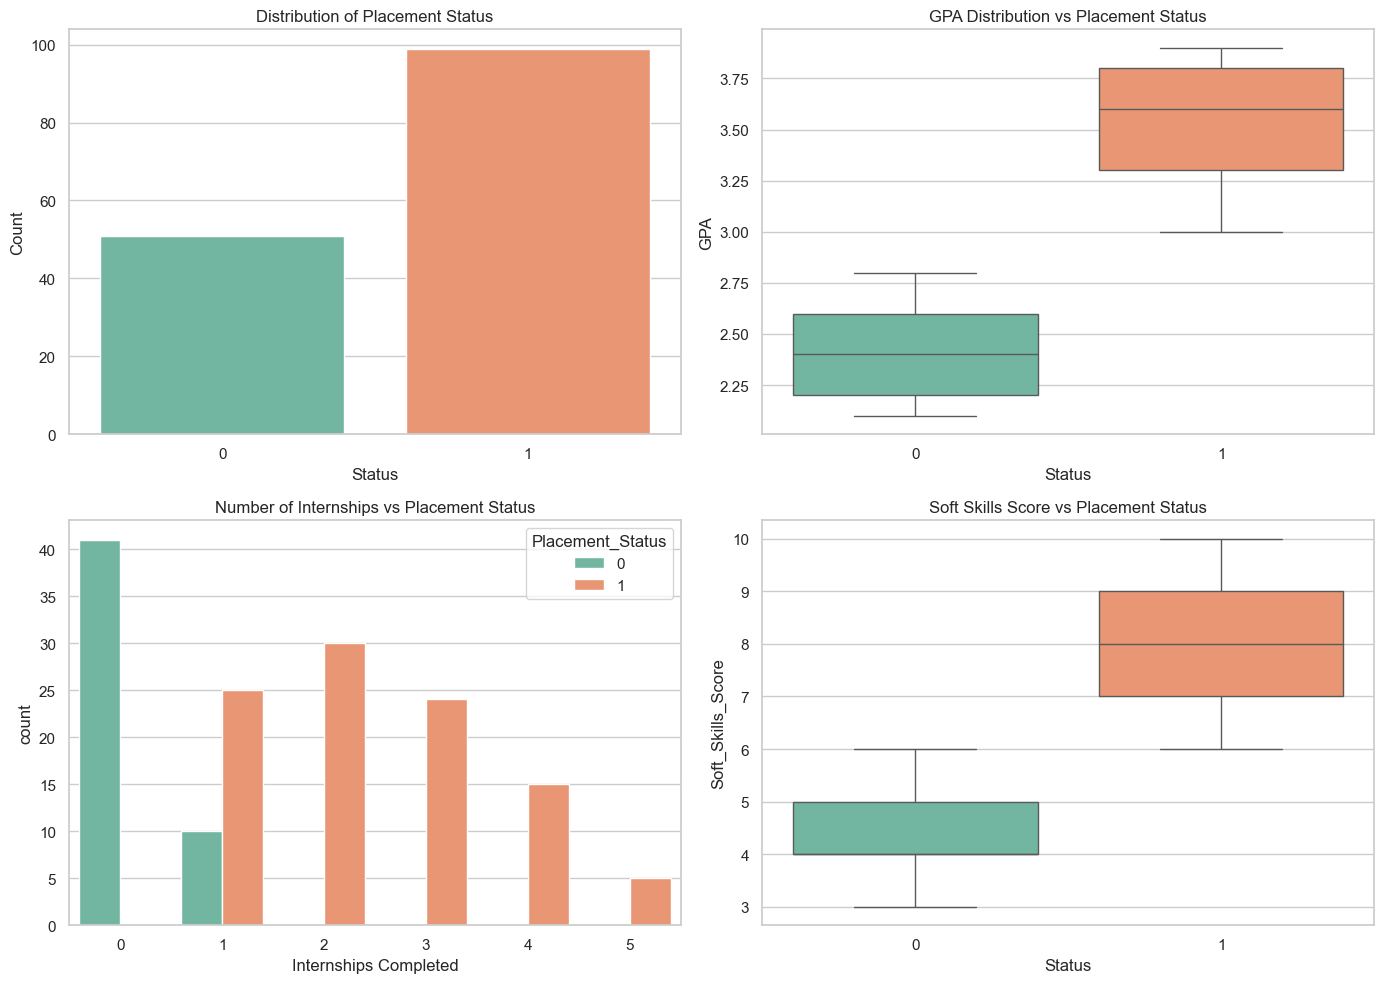

In [9]:
# Initialize a 2x2 subplot canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable Distribution (Fixed with hue & legend=False)
sns.countplot(data=df, x='Placement_Status', hue='Placement_Status', ax=axes[0,0], palette='Set2', legend=False)
axes[0,0].set_title('Distribution of Placement Status')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')

# 2. GPA Breakdown by Placement (Fixed with hue & legend=False)
sns.boxplot(data=df, x='Placement_Status', y='GPA', hue='Placement_Status', ax=axes[0,1], palette='Set2', legend=False)
axes[0,1].set_title('GPA Distribution vs Placement Status')
axes[0,1].set_xlabel('Status')

# 3. Impact of Internships on Placement (This one is fine since hue was already assigned)
sns.countplot(data=df, x='Internships', hue='Placement_Status', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Number of Internships vs Placement Status')
axes[1,0].set_xlabel('Internships Completed')

# 4. Soft Skills Impact (Fixed with hue & legend=False)
sns.boxplot(data=df, x='Placement_Status', y='Soft_Skills_Score', hue='Placement_Status', ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Soft Skills Score vs Placement Status')
axes[1,1].set_xlabel('Status')

plt.tight_layout()
plt.show()

---
### --- Preprocessing and Training ---

In [4]:
# Preprocessing
df['Placement_Status'] = df['Placement_Status'].map({'Placed': 1, 'Not Placed': 0})
X = df.drop(columns=['Student_ID', 'Placement_Status'])
y = df['Placement_Status']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Preprocessing and Training complete.")

Preprocessing and Training complete.


In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        21

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---
### Robust Model Validation & Feature Importances
Using Stratified K-Fold cross-validation to guarantee model stability, followed by extracting feature importances from our Random Forest architecture.

--- Cross-Validation Metrics ---
Scores across 5 Folds: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 100.00%

--- Feature Urgency Matrix ---


,Feature,Importance
0,GPA,0.414435
2,Projects,0.325156
3,Soft_Skills_Score,0.260410
1,Internships,0.000000


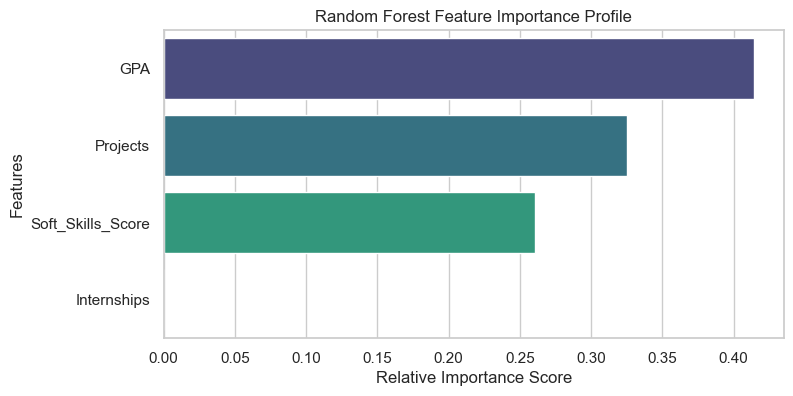

In [10]:
# 1. Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("--- Cross-Validation Metrics ---")
print(f"Scores across 5 Folds: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%\n")

# 2. Extract and Plot Feature Importance
importances = model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

print("--- Feature Urgency Matrix ---")
display(feature_df)

# Fixed with hue='Feature' and legend=False to clear the warning
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_df, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance Profile')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.show()

---
### Save the trained model to a file

In [7]:
joblib.dump(model, 'model.pkl')

print("Model saved as 'model.pkl' in the current directory.")

Model saved as 'model.pkl' in the current directory.


---
### Model Inference Pipeline
Simulating production-level usage by loading our serialized model file and scoring a live, hypothetical student profile.

In [8]:
# Load the frozen model binary
loaded_pipeline = joblib.load('model.pkl')

# Define an unseen candidate array tracking ['GPA', 'Internships', 'Projects', 'Soft_Skills_Score']
unseen_candidate = pd.DataFrame([{
    'GPA': 3.3,
    'Internships': 1,
    'Projects': 2,
    'Soft_Skills_Score': 7
}])

# Compute class assignments and raw probabilities
predicted_class = loaded_pipeline.predict(unseen_candidate)
placement_probability = loaded_pipeline.predict_proba(unseen_candidate)[0][1]

# Format production printout
final_status = "Placed" if predicted_class[0] == 1 else "Not Placed"

print("=== Live Inference Execution ===")
print(f"Target Candidate Summary: {unseen_candidate.iloc[0].to_dict()}")
print("-" * 40)
print(f"System Classification Verdict : {final_status}")
print(f"Confidence of Placement Success: {placement_probability * 100:.2f}%")

=== Live Inference Execution ===
Target Candidate Summary: {'GPA': 3.3, 'Internships': 1.0, 'Projects': 2.0, 'Soft_Skills_Score': 7.0}
----------------------------------------
System Classification Verdict : Placed
Confidence of Placement Success: 100.00%
